# Smart Energy Consumption Prediction System
## Data Engineering & Preprocessing Pipeline

**Team:** Data Engineering & Preprocessing
**Dataset:** Tetuan City Power Consumption (Tetouan, Morocco) — 52,416 rows, 10-minute interval smart meter readings for 3 distribution zones, alongside weather parameters.

**Objective:** Source, clean, and feature-engineer the raw dataset into a modeling-ready form, then hand off a documented, split, and scaled dataset to the Forecasting, Anomaly Detection, and Dashboard teams.

This notebook is run from `notebooks/` inside the project repository:

```
Smart-Energy-Consumption-Prediction-System/
├── data/
│   ├── raw/Tetuan_City_power_consumption.csv
│   └── processed/
│       ├── cleaned_energy_data.csv
│       ├── feature_engineered_energy_data.csv
│       ├── train.csv
│       ├── validation.csv
│       └── test.csv
├── notebooks/
│   ├── data_preprocessing.ipynb   <- this notebook
│   └── figures/
├── docs/feature_dictionary.md
├── README.md
└── requirements.txt
```

**Deliverables produced by this notebook:**
1. `data/processed/cleaned_energy_data.csv` — cleaned dataset (missing values, duplicates, outliers handled), *before* feature engineering
2. `data/processed/feature_engineered_energy_data.csv` — full feature-engineered dataset (unscaled), for EDA/dashboard/clustering use
3. `data/processed/train.csv`, `validation.csv`, `test.csv` — chronologically split (70/15/15), scaled, model-ready datasets
4. `notebooks/figures/` — exported PNGs of all EDA visualizations
5. `docs/feature_dictionary.md` — full data dictionary (generated as a separate file at the end of this notebook)

---

### Table of Contents
1. [Data Exploration & Quality Analysis (EDA)](#section1)
2. [Data Preprocessing & Outlier Handling](#section2)
3. [Advanced Feature Engineering](#section3)
4. [Train / Validation / Test Split & Feature Scaling](#section4)
5. [Exports & Deliverables](#section5)


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go

import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Dynamic project path detection (supports running from root or notebooks/ folder) ---
cwd = os.getcwd()
if os.path.basename(cwd) == 'notebooks':
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, '..'))
    FIG_DIR = os.path.join(cwd, 'figures')
else:
    PROJECT_ROOT = os.path.abspath(cwd)
    FIG_DIR = os.path.join(cwd, 'notebooks', 'figures')

RAW_PATH = os.path.join(PROJECT_ROOT, 'data', 'raw', 'Tetuan_City_power_consumption.csv')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
DOCS_DIR = os.path.join(PROJECT_ROOT, 'docs')

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DOCS_DIR, exist_ok=True)

print("Project root:", os.path.basename(PROJECT_ROOT))
print("Raw data:", os.path.relpath(RAW_PATH, PROJECT_ROOT))
print("Environment ready.")

Project root: Smart-Energy-Consumption-Prediction-System-1
Raw data: data/raw/Tetuan_City_power_consumption.csv
Environment ready.


<a id='section1'></a>
## 1. Data Exploration & Quality Analysis (EDA)

We load the raw CSV as-is (no assumptions about cleanliness) and profile it: shape, dtypes, missingness, duplicates, and descriptive statistics. This tells us exactly what preprocessing step 2 needs to handle.


In [2]:
df_raw = pd.read_csv(RAW_PATH)
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()


Shape: 52,416 rows x 9 columns


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [3]:
# Column names in the raw file have inconsistent spacing (e.g. 'Zone 2  Power Consumption'
# has a double space). We standardize them immediately so every later step is safe.
df_raw.columns = [' '.join(c.split()) for c in df_raw.columns]

RENAME_MAP = {
    'DateTime': 'DateTime',
    'Temperature': 'Temperature',
    'Humidity': 'Humidity',
    'Wind Speed': 'Wind_Speed',
    'general diffuse flows': 'General_Diffuse_Flows',
    'diffuse flows': 'Diffuse_Flows',
    'Zone 1 Power Consumption': 'Zone_1_Power_Consumption',
    'Zone 2 Power Consumption': 'Zone_2_Power_Consumption',
    'Zone 3 Power Consumption': 'Zone_3_Power_Consumption',
}
df_raw = df_raw.rename(columns=RENAME_MAP)
print("Standardized columns:", df_raw.columns.tolist())


Standardized columns: ['DateTime', 'Temperature', 'Humidity', 'Wind_Speed', 'General_Diffuse_Flows', 'Diffuse_Flows', 'Zone_1_Power_Consumption', 'Zone_2_Power_Consumption', 'Zone_3_Power_Consumption']


In [4]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   DateTime                  52416 non-null  str    
 1   Temperature               52416 non-null  float64
 2   Humidity                  52416 non-null  float64
 3   Wind_Speed                52416 non-null  float64
 4   General_Diffuse_Flows     52416 non-null  float64
 5   Diffuse_Flows             52416 non-null  float64
 6   Zone_1_Power_Consumption  52416 non-null  float64
 7   Zone_2_Power_Consumption  52416 non-null  float64
 8   Zone_3_Power_Consumption  52416 non-null  float64
dtypes: float64(8), str(1)
memory usage: 3.6 MB


In [5]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(3)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})


,missing_count,missing_pct
DateTime,0,0.0
Temperature,0,0.0
Humidity,0,0.0
Wind_Speed,0,0.0
General_Diffuse_Flows,0,0.0
Diffuse_Flows,0,0.0
Zone_1_Power_Consumption,0,0.0
Zone_2_Power_Consumption,0,0.0
Zone_3_Power_Consumption,0,0.0


In [6]:
n_dupes = df_raw.duplicated().sum()
n_dupe_ts = df_raw['DateTime'].duplicated().sum()
print(f"Fully duplicated rows: {n_dupes}")
print(f"Duplicate DateTime values: {n_dupe_ts}")


Fully duplicated rows: 0
Duplicate DateTime values: 0


In [7]:
df_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
Temperature,52416.0,18.810024,5.815476,3.247000,14.410000,18.780000,22.890000,40.01000
Humidity,52416.0,68.259518,15.551177,11.340000,58.310000,69.860000,81.400000,94.80000
Wind_Speed,52416.0,1.959489,2.348862,0.050000,0.078000,0.086000,4.915000,6.48300
General_Diffuse_Flows,52416.0,182.696614,264.400960,0.004000,0.062000,5.035500,319.600000,1163.00000
Diffuse_Flows,52416.0,75.028022,124.210949,0.011000,0.122000,4.456000,101.000000,936.00000
Zone_1_Power_Consumption,52416.0,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.39512
Zone_2_Power_Consumption,52416.0,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.717520,37408.86076
Zone_3_Power_Consumption,52416.0,17835.406218,6622.165099,5935.174070,13129.326630,16415.117470,21624.100420,47598.32636


**Findings so far:** this snapshot has no missing values and no duplicate rows/timestamps — but the code is written defensively (it reports counts rather than assuming zero), so this notebook is safe to reuse against a different, dirtier data pull. Section 2 still runs the full missing-value/duplicate-handling logic rather than skipping it.

Next, we parse `DateTime` into a proper datetime column and sort chronologically — required before any time-aware plot or the lag/rolling features later.


In [8]:
df = df_raw.copy()
df['DateTime'] = pd.to_datetime(df['DateTime'], format='%m/%d/%Y %H:%M')
df = df.sort_values('DateTime').reset_index(drop=True)

print(f"Date range: {df['DateTime'].min()} -> {df['DateTime'].max()}")
full_range = pd.date_range(df['DateTime'].min(), df['DateTime'].max(), freq='10min')
missing_timestamps = full_range.difference(df['DateTime'])
print(f"Missing timestamps (gaps in the series): {len(missing_timestamps)}")


Date range: 2017-01-01 00:00:00 -> 2017-12-30 23:50:00
Missing timestamps (gaps in the series): 0


### Figure 1 — Time-Series Line Plot of Zone 1, 2, 3 Power Consumption

In [9]:
fig1 = go.Figure()
for col, name, color in [
    ('Zone_1_Power_Consumption', 'Zone 1', '#1f77b4'),
    ('Zone_2_Power_Consumption', 'Zone 2', '#ff7f0e'),
    ('Zone_3_Power_Consumption', 'Zone 3', '#2ca02c'),
]:
    fig1.add_trace(go.Scatter(x=df['DateTime'], y=df[col], mode='lines', name=name,
                               line=dict(width=1, color=color)))
fig1.update_layout(title='Power Consumption by Zone Over Time (Tetuan City)',
                    xaxis_title='DateTime', yaxis_title='Power Consumption (Watts)',
                    template='plotly_white', height=500,
                    legend=dict(orientation='h', y=1.02, x=1, xanchor='right'))
fig1.show()


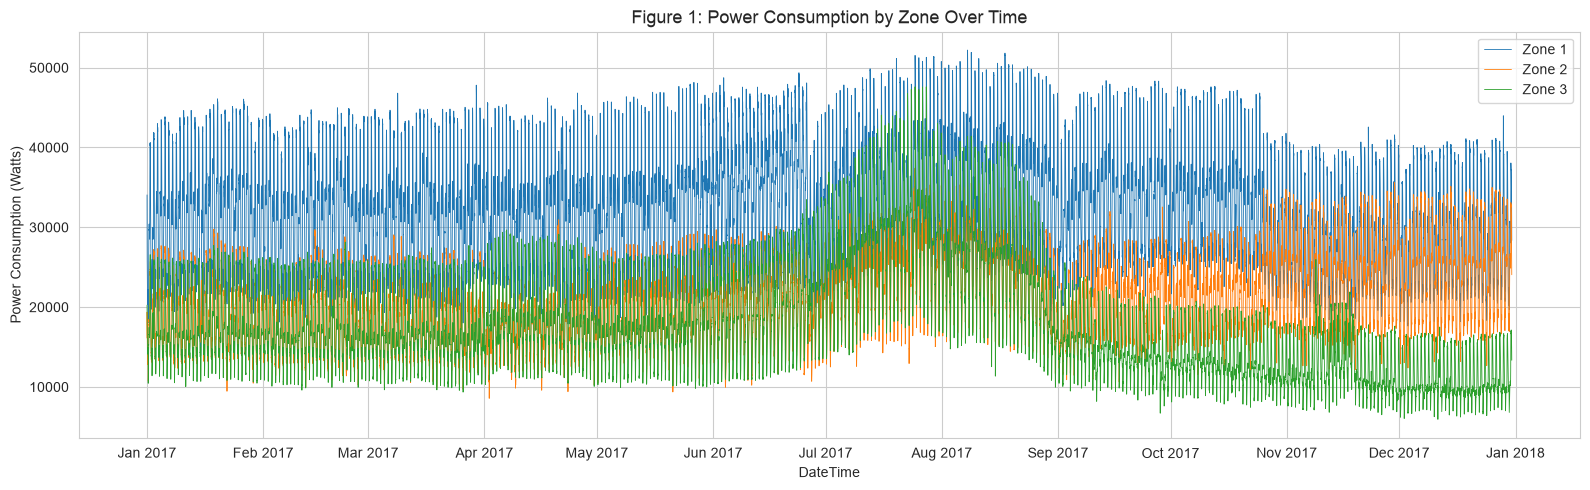

In [10]:
fig, ax = plt.subplots(figsize=(16, 5))
for col, name in [('Zone_1_Power_Consumption', 'Zone 1'),
                   ('Zone_2_Power_Consumption', 'Zone 2'),
                   ('Zone_3_Power_Consumption', 'Zone 3')]:
    ax.plot(df['DateTime'], df[col], label=name, linewidth=0.6)
ax.set_title('Figure 1: Power Consumption by Zone Over Time', fontsize=13)
ax.set_xlabel('DateTime'); ax.set_ylabel('Power Consumption (Watts)')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig1_timeseries_by_zone.png'), dpi=150)
plt.show()


### Figure 2 — Correlation Heatmap (Weather variables vs Power Consumption across Zones)

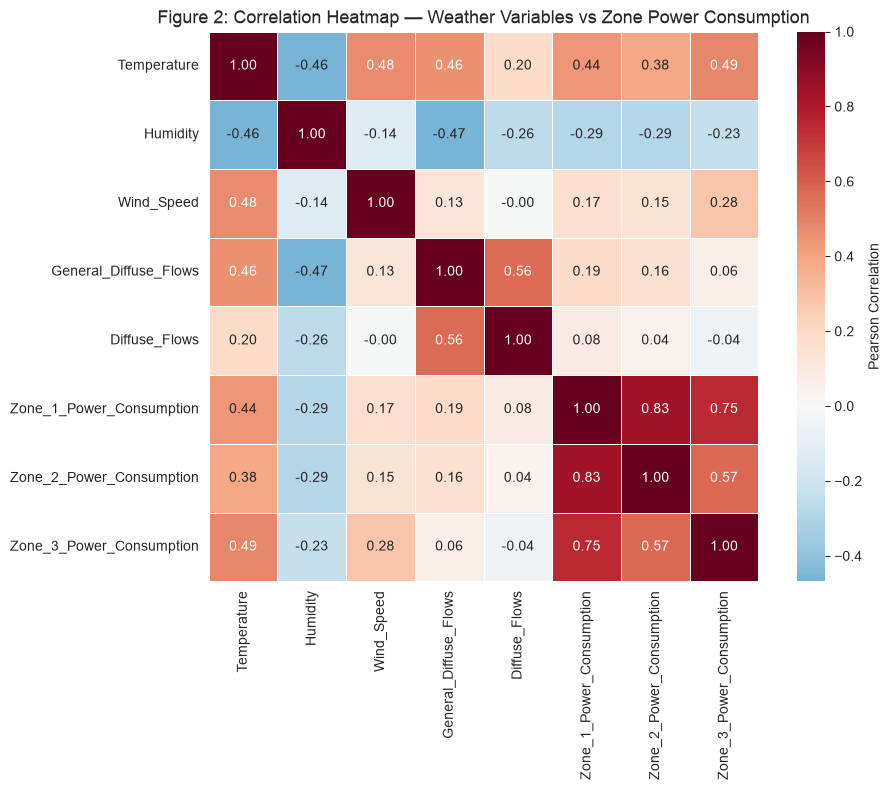

In [11]:
corr_cols = ['Temperature', 'Humidity', 'Wind_Speed', 'General_Diffuse_Flows', 'Diffuse_Flows',
             'Zone_1_Power_Consumption', 'Zone_2_Power_Consumption', 'Zone_3_Power_Consumption']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'}, ax=ax)
ax.set_title('Figure 2: Correlation Heatmap — Weather Variables vs Zone Power Consumption', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig2_correlation_heatmap.png'), dpi=150)
plt.show()


### Figure 3 — Daily & Monthly Average Power Consumption Profiles

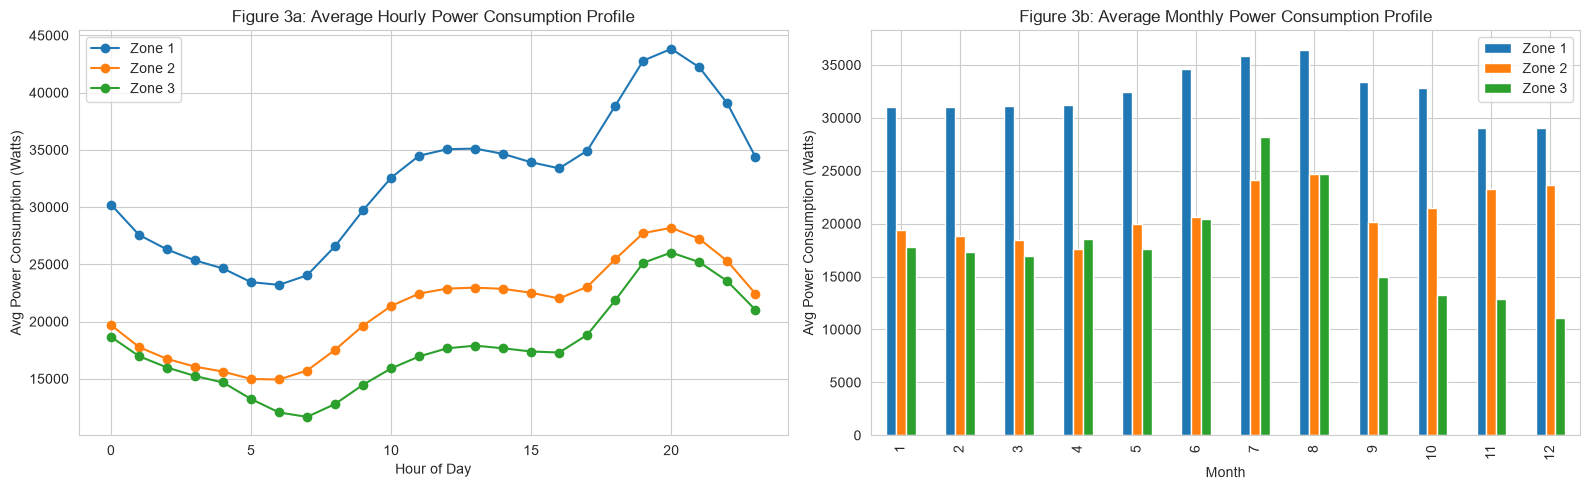

In [12]:
df['_hour_tmp'] = df['DateTime'].dt.hour
hourly_profile = df.groupby('_hour_tmp')[['Zone_1_Power_Consumption',
                                           'Zone_2_Power_Consumption',
                                           'Zone_3_Power_Consumption']].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
hourly_profile.plot(ax=axes[0], marker='o')
axes[0].set_title('Figure 3a: Average Hourly Power Consumption Profile', fontsize=12)
axes[0].set_xlabel('Hour of Day'); axes[0].set_ylabel('Avg Power Consumption (Watts)')
axes[0].legend(['Zone 1', 'Zone 2', 'Zone 3'])

df['_month_tmp'] = df['DateTime'].dt.month
monthly_profile = df.groupby('_month_tmp')[['Zone_1_Power_Consumption',
                                             'Zone_2_Power_Consumption',
                                             'Zone_3_Power_Consumption']].mean()
monthly_profile.plot(kind='bar', ax=axes[1])
axes[1].set_title('Figure 3b: Average Monthly Power Consumption Profile', fontsize=12)
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Avg Power Consumption (Watts)')
axes[1].legend(['Zone 1', 'Zone 2', 'Zone 3'])

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig3_daily_monthly_profiles.png'), dpi=150)
plt.show()

df.drop(columns=['_month_tmp'], inplace=True)


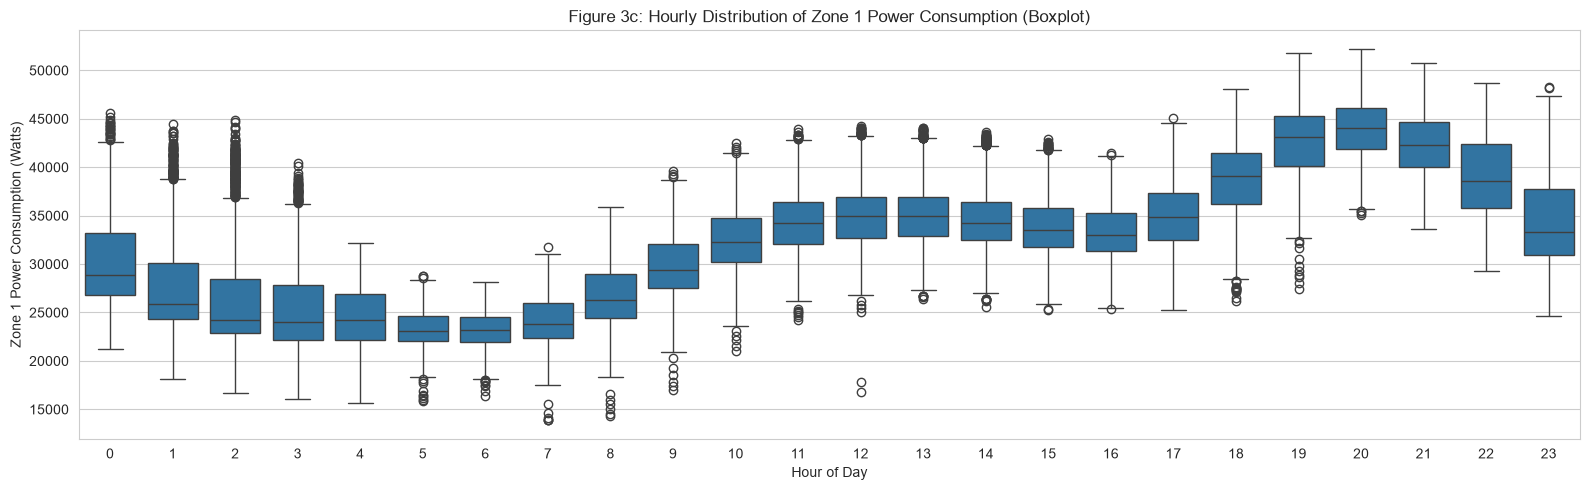

In [13]:
fig, ax = plt.subplots(figsize=(16, 5))
sns.boxplot(data=df, x='_hour_tmp', y='Zone_1_Power_Consumption', ax=ax, color='#1f77b4')
ax.set_title('Figure 3c: Hourly Distribution of Zone 1 Power Consumption (Boxplot)', fontsize=12)
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Zone 1 Power Consumption (Watts)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig3c_hourly_boxplot_zone1.png'), dpi=150)
plt.show()

df.drop(columns=['_hour_tmp'], inplace=True)


<a id='section2'></a>
## 2. Data Preprocessing & Outlier Handling

We (1) defensively re-check/handle missing values and duplicates, (2) detect outliers in the power-consumption columns via IQR, (3) visualize before/after, and (4) treat by **capping (winsorizing)** rather than deleting rows — deletion would break the fixed 10-minute grid the lag/rolling features need.

At the end of this section we export **`cleaned_energy_data.csv`** — cleaned, but *before* feature engineering — since some downstream teams (e.g. anomaly detection baselines) want the cleaned series without the modeling-specific engineered columns.


In [14]:
before_rows = len(df)
df = df.drop_duplicates()
df = df.drop_duplicates(subset='DateTime', keep='first')

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].ffill().bfill()

after_rows = len(df)
print(f"Rows before cleaning: {before_rows} | after: {after_rows} | removed: {before_rows - after_rows}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")


Rows before cleaning: 52416 | after: 52416 | removed: 0
Remaining missing values: 0


In [15]:
zone_cols = ['Zone_1_Power_Consumption', 'Zone_2_Power_Consumption', 'Zone_3_Power_Consumption']

def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_summary, bounds = {}, {}
for col in zone_cols:
    lower, upper = iqr_bounds(df[col])
    bounds[col] = (lower, upper)
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = {'lower_bound': round(lower, 2), 'upper_bound': round(upper, 2),
                             'n_outliers': int(n_out), 'pct_outliers': round(n_out / len(df) * 100, 3)}

pd.DataFrame(outlier_summary).T


,lower_bound,upper_bound,n_outliers,pct_outliers
Zone_1_Power_Consumption,9813.14,53806.54,0.0,0.000
Zone_2_Power_Consumption,5381.34,36313.14,7.0,0.013
Zone_3_Power_Consumption,387.17,34366.26,1191.0,2.272


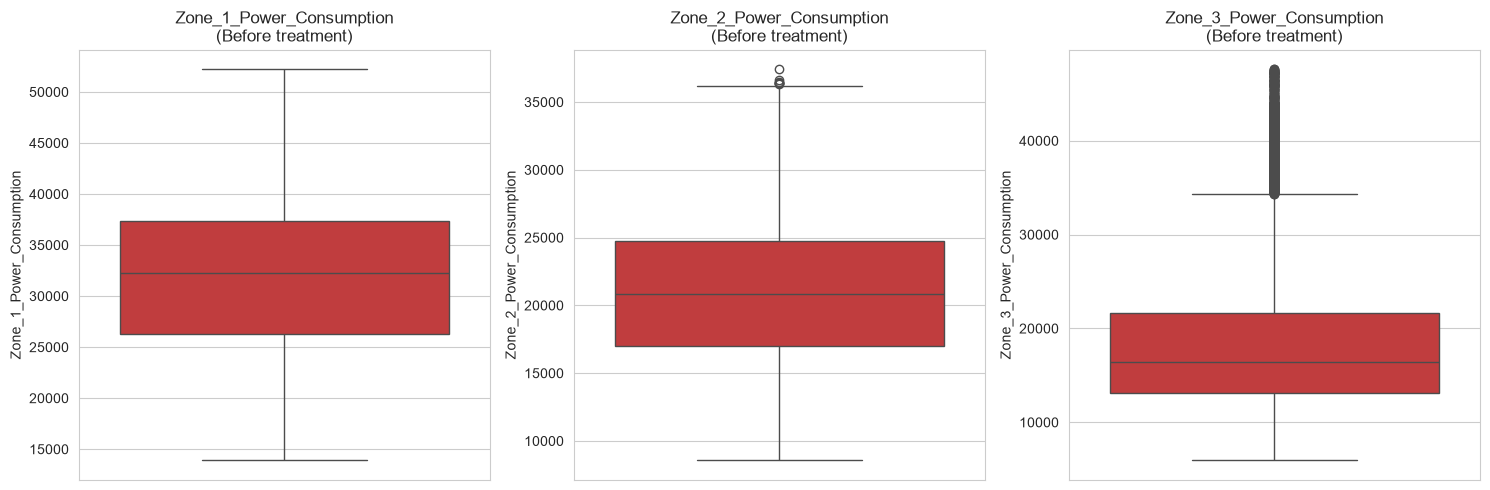

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, zone_cols):
    sns.boxplot(y=df[col], ax=ax, color='#d62728')
    ax.set_title(f'{col}\n(Before treatment)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig4_boxplots_before_outlier_treatment.png'), dpi=150)
plt.show()


In [17]:
for col in zone_cols:
    lower, upper = bounds[col]
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outlier capping applied (IQR method, k=1.5) to:", zone_cols)


Outlier capping applied (IQR method, k=1.5) to: ['Zone_1_Power_Consumption', 'Zone_2_Power_Consumption', 'Zone_3_Power_Consumption']


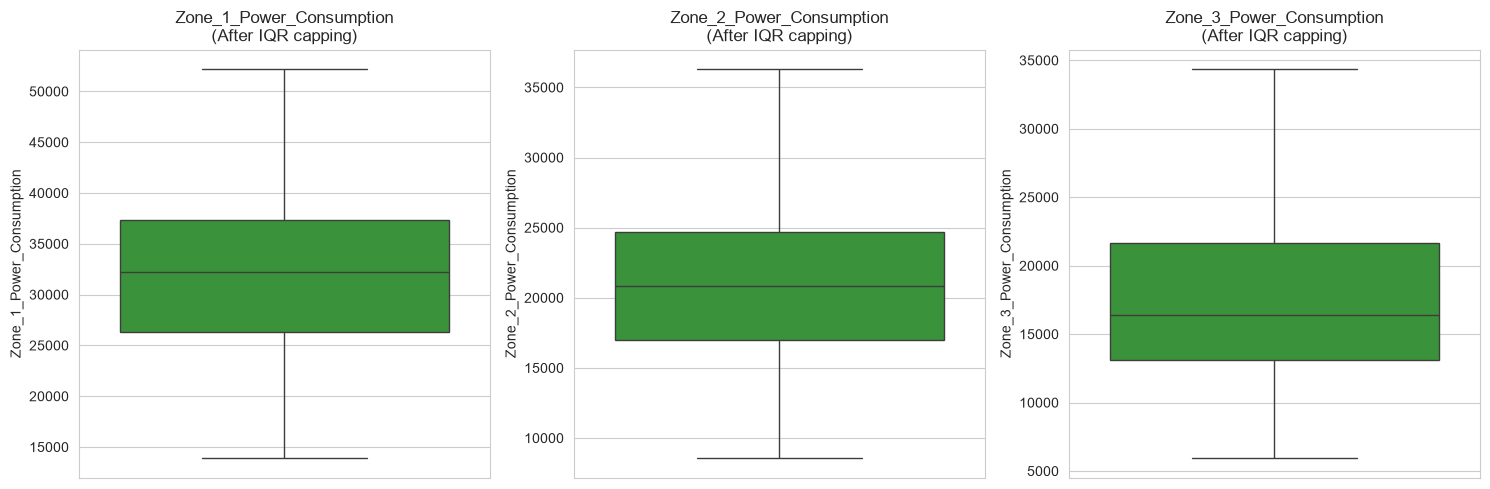

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, zone_cols):
    sns.boxplot(y=df[col], ax=ax, color='#2ca02c')
    ax.set_title(f'{col}\n(After IQR capping)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig5_boxplots_after_outlier_treatment.png'), dpi=150)
plt.show()


> **Note for the Anomaly Detection team:** `cleaned_energy_data.csv` (exported below) reflects the *treated* series. If your detector should train on the naturally occurring extremes, use `data/raw/Tetuan_City_power_consumption.csv` for target labels/thresholds and treat this cleaned file as the expected/baseline pattern instead.


In [19]:
# --- Export 1: CLEANED dataset (pre-feature-engineering) ---
cleaned_path = os.path.join(PROCESSED_DIR, 'cleaned_energy_data.csv')
df.to_csv(cleaned_path, index=False)
rel_cleaned_path = os.path.relpath(cleaned_path, PROJECT_ROOT)
print(f"Saved {rel_cleaned_path} — {df.shape[0]:,} rows x {df.shape[1]} columns")

Saved data/processed/cleaned_energy_data.csv — 52,416 rows x 9 columns


<a id='section3'></a>
## 3. Advanced Feature Engineering

Built on the cleaned, chronologically-sorted, gap-free 10-minute grid from Section 2.

- **Time-based features** — hour, day of week, month, quarter, weekend flag, season, peak-hour flag
- **Lag features** — prior consumption values (10 min / 1 hr / 24 hr ago), per zone
- **Rolling window statistics** — 1-hour and 24-hour rolling mean/std/min/max, per zone
- **Weather interaction index** — heat-index approximation from temperature + humidity


### 3.1 Time-Based Features

In [20]:
df['Hour'] = df['DateTime'].dt.hour
df['Day_of_Week'] = df['DateTime'].dt.dayofweek
df['Month'] = df['DateTime'].dt.month
df['Quarter'] = df['DateTime'].dt.quarter
df['Is_Weekend'] = (df['Day_of_Week'] >= 5).astype(int)

def month_to_season(m):
    if m in (12, 1, 2):
        return 'Winter'
    elif m in (3, 4, 5):
        return 'Spring'
    elif m in (6, 7, 8):
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(month_to_season)
df['Is_Peak_Hour'] = df['Hour'].apply(lambda h: 1 if 18 <= h < 22 else 0)

df[['DateTime', 'Hour', 'Day_of_Week', 'Month', 'Quarter', 'Is_Weekend', 'Season', 'Is_Peak_Hour']].head()


,DateTime,Hour,Day_of_Week,Month,Quarter,Is_Weekend,Season,Is_Peak_Hour
0,2017-01-01 00:00:00,0,6,1,1,1,Winter,0
1,2017-01-01 00:10:00,0,6,1,1,1,Winter,0
2,2017-01-01 00:20:00,0,6,1,1,1,Winter,0
3,2017-01-01 00:30:00,0,6,1,1,1,Winter,0
4,2017-01-01 00:40:00,0,6,1,1,1,Winter,0


### 3.2 Lag Features

`lag_1` = 10 minutes ago, `lag_6` = 1 hour ago, `lag_144` = 24 hours ago (10-minute sampling).


In [21]:
LAG_STEPS = {'lag_1': 1, 'lag_6': 6, 'lag_144': 144}

for zone_col, zone_name in [('Zone_1_Power_Consumption', 'Zone_1'),
                             ('Zone_2_Power_Consumption', 'Zone_2'),
                             ('Zone_3_Power_Consumption', 'Zone_3')]:
    for suffix, steps in LAG_STEPS.items():
        df[f'{zone_name}_{suffix}'] = df[zone_col].shift(steps)

lag_cols = [c for c in df.columns if '_lag_' in c]
df[lag_cols].head(3)


,Zone_1_lag_1,Zone_1_lag_6,Zone_1_lag_144,Zone_2_lag_1,Zone_2_lag_6,Zone_2_lag_144,Zone_3_lag_1,Zone_3_lag_6,Zone_3_lag_144
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,34055.69620,NaN,NaN,16128.87538,NaN,NaN,20240.96386,NaN,NaN
2,29814.68354,NaN,NaN,19375.07599,NaN,NaN,20131.08434,NaN,NaN


### 3.3 Rolling Window Statistics

Computed on `.shift(1)` so the statistic at row *t* only uses information through *t-1* — this avoids leaking the current target value into its own feature.


In [22]:
ROLLING_WINDOWS = {'1h': 6, '24h': 144}

for zone_col, zone_name in [('Zone_1_Power_Consumption', 'Zone_1'),
                             ('Zone_2_Power_Consumption', 'Zone_2'),
                             ('Zone_3_Power_Consumption', 'Zone_3')]:
    shifted = df[zone_col].shift(1)
    for label, window in ROLLING_WINDOWS.items():
        roll = shifted.rolling(window=window, min_periods=1)
        df[f'{zone_name}_roll_mean_{label}'] = roll.mean()
        df[f'{zone_name}_roll_std_{label}'] = roll.std()
        df[f'{zone_name}_roll_min_{label}'] = roll.min()
        df[f'{zone_name}_roll_max_{label}'] = roll.max()

roll_cols = [c for c in df.columns if '_roll_' in c]
print(f"Created {len(roll_cols)} rolling-window features.")
df[roll_cols[:8]].head(3)


Created 24 rolling-window features.


,Zone_1_roll_mean_1h,Zone_1_roll_std_1h,Zone_1_roll_min_1h,Zone_1_roll_max_1h,Zone_1_roll_mean_24h,Zone_1_roll_std_24h,Zone_1_roll_min_24h,Zone_1_roll_max_24h
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,34055.69620,NaN,34055.69620,34055.6962,34055.69620,NaN,34055.69620,34055.6962
2,31935.18987,2998.848811,29814.68354,34055.6962,31935.18987,2998.848811,29814.68354,34055.6962


### 3.4 Weather Interaction Index

`Temp_Humidity_Index` approximates the NOAA heat-index formula (simplified linear form), capturing how temperature and humidity jointly drive cooling demand.


In [23]:
df['Temp_Humidity_Index'] = df['Temperature'] + 0.5555 * (
    0.06 * df['Humidity'] * df['Temperature'] - 10 - df['Humidity']
)
df[['DateTime', 'Temperature', 'Humidity', 'Temp_Humidity_Index']].head()


,DateTime,Temperature,Humidity,Temp_Humidity_Index
0,2017-01-01 00:00:00,6.559,73.8,-23.858374
1,2017-01-01 00:10:00,6.414,74.5,-24.599243
2,2017-01-01 00:20:00,6.313,74.5,-24.951034
3,2017-01-01 00:30:00,6.121,75.0,-25.795530
4,2017-01-01 00:40:00,5.921,75.7,-26.746187


In [24]:
n_incomplete = df[lag_cols].isnull().any(axis=1).sum()
print(f"Rows with at least one missing lag feature (start-of-series edge effect): {n_incomplete}")
print("These correspond to the first 144 rows (24h at 10-min resolution).")


Rows with at least one missing lag feature (start-of-series edge effect): 144
These correspond to the first 144 rows (24h at 10-min resolution).


In [25]:
# --- Export 2: FEATURE-ENGINEERED dataset (unscaled, all rows incl. edge-case NaNs) ---
df_feat_export = df.copy()
df_feat_export = pd.get_dummies(df_feat_export, columns=['Season'], prefix='Season')
feat_path = os.path.join(PROCESSED_DIR, 'feature_engineered_energy_data.csv')
df_feat_export.to_csv(feat_path, index=False)
rel_feat_path = os.path.relpath(feat_path, PROJECT_ROOT)
print(f"Saved {rel_feat_path} — {df_feat_export.shape[0]:,} rows x {df_feat_export.shape[1]} columns")

Saved data/processed/feature_engineered_energy_data.csv — 52,416 rows x 53 columns


<a id='section4'></a>
## 4. Train / Validation / Test Split & Feature Scaling

### 4.1 Chronological Split (70% / 15% / 15%)

Time series data must never be shuffled before splitting — that would leak future information into training. We use a sequential split: the first 70% of rows form the training set, the next 15% form validation (for hyperparameter tuning / early stopping on the LSTM-GRU and regression models), and the final 15% form the held-out test set.


In [26]:
TRAIN_RATIO, VAL_RATIO = 0.70, 0.15  # remaining 0.15 is test

n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

for name, part in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    print(f"{name}: {len(part):,} rows  ({part['DateTime'].min()} -> {part['DateTime'].max()})")


Train: 36,691 rows  (2017-01-01 00:00:00 -> 2017-09-12 19:00:00)
Validation: 7,862 rows  (2017-09-12 19:10:00 -> 2017-11-06 09:20:00)
Test: 7,863 rows  (2017-11-06 09:30:00 -> 2017-12-30 23:50:00)


In [27]:
# Drop rows with NaN lag/rolling features from TRAIN only (start-of-series edge effect).
# Validation and test must remain fully scoreable, so we forward/back-fill instead of dropping —
# matching how a live deployment would have to handle any early NaNs.
train_df = train_df.dropna(subset=lag_cols + roll_cols).reset_index(drop=True)
val_df[lag_cols + roll_cols] = val_df[lag_cols + roll_cols].ffill().bfill()
test_df[lag_cols + roll_cols] = test_df[lag_cols + roll_cols].ffill().bfill()

print(f"Train after dropping incomplete-history rows: {len(train_df):,} rows")
print(f"Validation rows: {len(val_df):,} | remaining NaNs: {val_df.isnull().sum().sum()}")
print(f"Test rows: {len(test_df):,} | remaining NaNs: {test_df.isnull().sum().sum()}")


Train after dropping incomplete-history rows: 36,547 rows
Validation rows: 7,862 | remaining NaNs: 0
Test rows: 7,863 | remaining NaNs: 0


### 4.2 Feature Scaling

`MinMaxScaler` (range [0, 1]) — a common choice for LSTM/GRU inputs. **Fit only on the training set**, then applied to transform validation and test, so no leakage of their statistics into training.

`Season` is one-hot encoded (categorical, not scaled); `DateTime` is retained as-is for indexing.


In [28]:
train_df = pd.get_dummies(train_df, columns=['Season'], prefix='Season')
val_df = pd.get_dummies(val_df, columns=['Season'], prefix='Season')
test_df = pd.get_dummies(test_df, columns=['Season'], prefix='Season')

# Align one-hot columns across all three splits in case a season is missing from one
all_cols = sorted(set(train_df.columns) | set(val_df.columns) | set(test_df.columns))
train_df = train_df.reindex(columns=all_cols, fill_value=0)
val_df = val_df.reindex(columns=all_cols, fill_value=0)
test_df = test_df.reindex(columns=all_cols, fill_value=0)

cols_ordered = ['DateTime'] + [c for c in all_cols if c != 'DateTime']
train_df, val_df, test_df = train_df[cols_ordered], val_df[cols_ordered], test_df[cols_ordered]

print("Season one-hot columns:", [c for c in cols_ordered if c.startswith('Season_')])


Season one-hot columns: ['Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter']


In [29]:
exclude_from_scaling = ['DateTime']
scale_cols = [c for c in train_df.columns if c not in exclude_from_scaling]

scaler = MinMaxScaler()
train_scaled, val_scaled, test_scaled = train_df.copy(), val_df.copy(), test_df.copy()

train_scaled[scale_cols] = scaler.fit_transform(train_df[scale_cols])
val_scaled[scale_cols] = scaler.transform(val_df[scale_cols])
test_scaled[scale_cols] = scaler.transform(test_df[scale_cols])

print("Scaling complete (fit on train only). Train min/max should be ~0/~1:")
train_scaled[scale_cols].describe().loc[['min', 'max']].T.head(10)


Scaling complete (fit on train only). Train min/max should be ~0/~1:


,min,max
Day_of_Week,0.0,1.0
Diffuse_Flows,0.0,1.0
General_Diffuse_Flows,0.0,1.0
Hour,0.0,1.0
Humidity,0.0,1.0
Is_Peak_Hour,0.0,1.0
Is_Weekend,0.0,1.0
Month,0.0,1.0
Quarter,0.0,1.0
Season_Autumn,0.0,1.0


<a id='section5'></a>
## 5. Exports & Deliverables

Final exports to `data/processed/`: `train.csv`, `validation.csv`, `test.csv` (all scaled, feature-complete). Figures are saved to `notebooks/figures/`, and the data dictionary is written to `docs/feature_dictionary.md`.


In [30]:
train_scaled.to_csv(os.path.join(PROCESSED_DIR, 'train.csv'), index=False)
val_scaled.to_csv(os.path.join(PROCESSED_DIR, 'validation.csv'), index=False)
test_scaled.to_csv(os.path.join(PROCESSED_DIR, 'test.csv'), index=False)

print(f"Saved data/processed/train.csv      — {train_scaled.shape[0]:,} rows x {train_scaled.shape[1]} columns")
print(f"Saved data/processed/validation.csv — {val_scaled.shape[0]:,} rows x {val_scaled.shape[1]} columns")
print(f"Saved data/processed/test.csv       — {test_scaled.shape[0]:,} rows x {test_scaled.shape[1]} columns")

print("\nFigures saved to notebooks/figures/:")
for f in sorted(os.listdir(FIG_DIR)):
    if not f.startswith('.'):
        print(" -", f)

print("\nAll processed files in data/processed/:")
for f in sorted(os.listdir(PROCESSED_DIR)):
    if not f.startswith('.'):
        print(" -", f)

Saved data/processed/train.csv      — 36,547 rows x 53 columns
Saved data/processed/validation.csv — 7,862 rows x 53 columns
Saved data/processed/test.csv       — 7,863 rows x 53 columns

Figures saved to notebooks/figures/:
 - fig1_timeseries_by_zone.png
 - fig2_correlation_heatmap.png
 - fig3_daily_monthly_profiles.png
 - fig3c_hourly_boxplot_zone1.png
 - fig4_boxplots_before_outlier_treatment.png
 - fig5_boxplots_after_outlier_treatment.png

All processed files in data/processed/:
 - cleaned_energy_data.csv
 - feature_engineered_energy_data.csv
 - test.csv
 - train.csv
 - validation.csv


## Next Steps

The full column-by-column data dictionary is maintained separately at **`docs/feature_dictionary.md`** (generated alongside this notebook) so it can be version-controlled and read independently by the Forecasting, Anomaly Detection, Clustering, and Dashboard teams without opening Jupyter.

**Quick reference — which file to use:**
- **Forecasting / Regression / LSTM-GRU team:** `data/processed/train.csv`, `validation.csv`, `test.csv` (scaled, chronologically split, no leakage)
- **Anomaly Detection team:** `data/processed/cleaned_energy_data.csv` or `feature_engineered_energy_data.csv` (unscaled, original units); cross-reference `data/raw/` for pre-capping extreme values
- **Clustering team:** `data/processed/feature_engineered_energy_data.csv` (has `Season_*`, `Hour`, `Is_Peak_Hour` for load-profile clustering)
- **Dashboard team:** `data/processed/feature_engineered_energy_data.csv` (unscaled, human-readable, full `DateTime` column)
